In [19]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

In [20]:
# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

In [21]:
from evaluation import financial_metrics

In [22]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## Prepare backtest results

In [23]:
base_r1 = pd.read_csv(os.path.join(DATA_DIR, 'base_r1_20251214_0648.csv'))
base_r2 = pd.read_csv(os.path.join(DATA_DIR, 'base_r2_20251213_2014.csv'))
mamba_r1 = pd.read_csv(os.path.join(DATA_DIR, 'mamba_r1_20251214_0519.csv'))
mamba_r2 = pd.read_csv(os.path.join(DATA_DIR, 'mamba_r2_20251213_0827.csv'))

In [24]:
window_size = 56

# trading begins after window_size steps
# i.e. first state is at idx = window_size - 1
base_r1 = base_r1.iloc[window_size-1:, :].reset_index(drop=True)
base_r2 = base_r2.iloc[window_size-1:, :].reset_index(drop=True)
mamba_r1 = mamba_r1.iloc[window_size-1:, :].reset_index(drop=True)
mamba_r2 = mamba_r2.iloc[window_size-1:, :].reset_index(drop=True)

In [25]:
price_cols = [col for col in mamba_r1.columns if 'price' in col]
share_cols = [col for col in mamba_r1.columns if 'share' in col]

## Generate metrics

In [26]:
# generate metrics on strategy
metrics_base_r1 = financial_metrics.financial_performance(base_r1)
metrics_base_r2 = financial_metrics.financial_performance(base_r2)
metrics_mamba_r1 = financial_metrics.financial_performance(mamba_r1)
metrics_mamba_r2 = financial_metrics.financial_performance(mamba_r2)

metrics_df = pd.DataFrame([
    metrics_base_r1,
    metrics_base_r2,
    metrics_mamba_r1,
    metrics_mamba_r2
]).T

metrics_df.columns = ['base_r1', 'base_r2', 'mamba_r1', 'mamba_r2']

metrics_df.round(3)

,base_r1,base_r2,mamba_r1,mamba_r2
total_return,5.746,2.281,1.217,5.173
CAGR,0.282,0.167,0.109,0.267
volatility,0.291,0.286,0.201,0.298
Sharpe,0.998,0.682,0.617,0.943
VaR,0.028,0.026,0.018,0.029
turnover,0.002,0.002,0.001,0.002


In [27]:
# generate metrics on stock prices
stock_eval = []
for col in price_cols:
    series = mamba_r1[col].values
    stock_eval.append({
        'stock': col,
        'return': financial_metrics.get_total_return(series),
        'sharpe': financial_metrics.get_sharpe_ratio(series)
    })
stock_eval = pd.DataFrame(stock_eval)
stock_eval.sort_values('return', ascending=False).round(3)

,stock,return,sharpe
5,price_NVDA,29.488,1.119
0,price_AAPL,6.021,0.971
4,price_MSFT,4.823,0.947
3,price_JPM,2.548,0.710
1,price_AMZN,1.971,0.582
7,price_SPY,1.926,0.813
6,price_PG,1.303,0.642
9,price_XOM,1.263,0.502
2,price_F,0.812,0.393
8,price_UNH,0.730,0.387


## Visualize trading

In [28]:
def visualize_trading(df):
    n_stocks = df.shape[1]

    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 0.8 * n_stocks), sharex=True)
    axes = axes.flatten()

    for ax, stock in zip(axes, df.columns):
        ax.plot(df.index, df[stock])
        ax.set_title(stock)
        ax.set_ylabel("Shares")
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

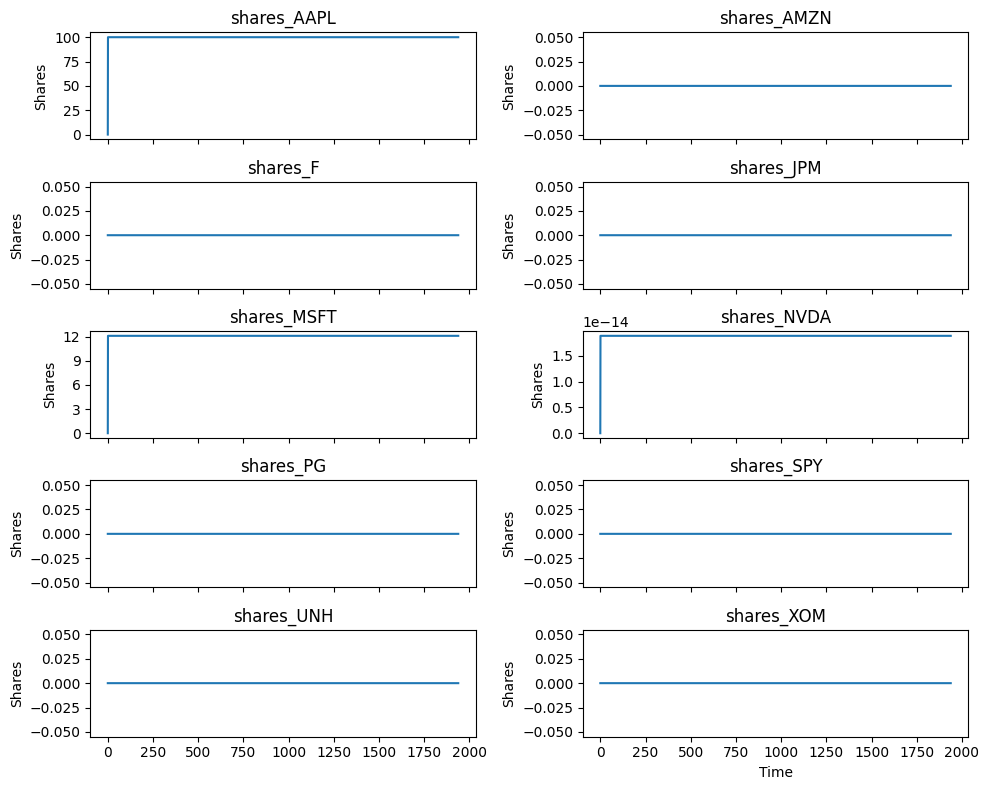

In [29]:
visualize_trading(base_r1[share_cols])

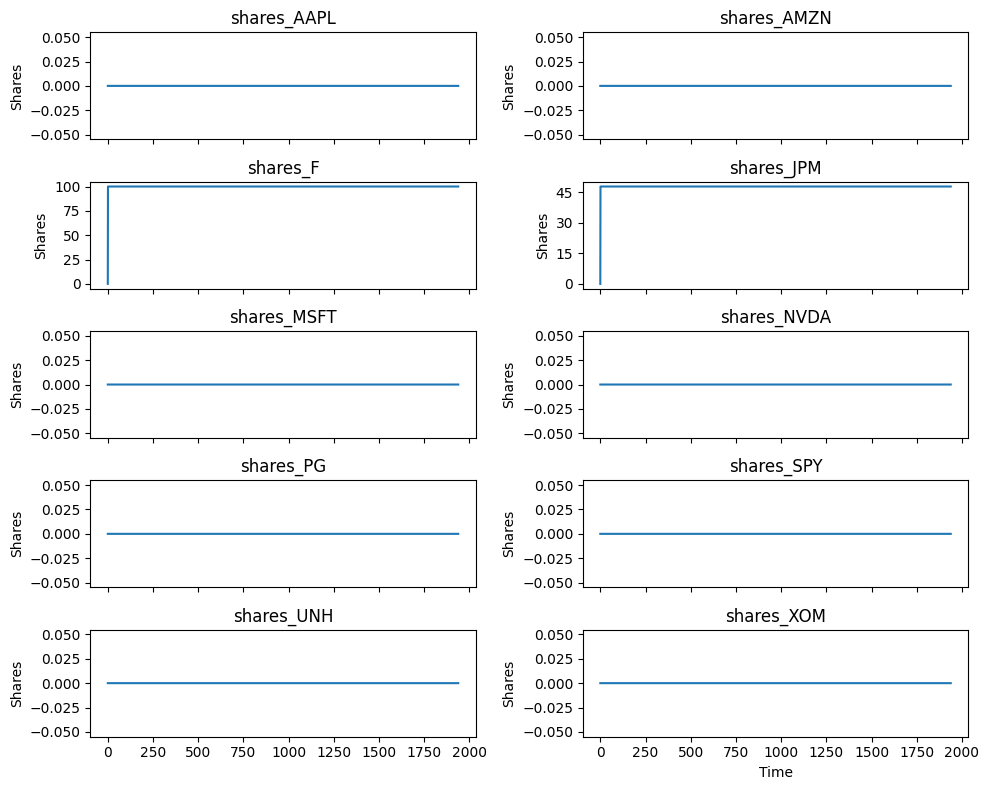

In [30]:
visualize_trading(base_r2[share_cols])

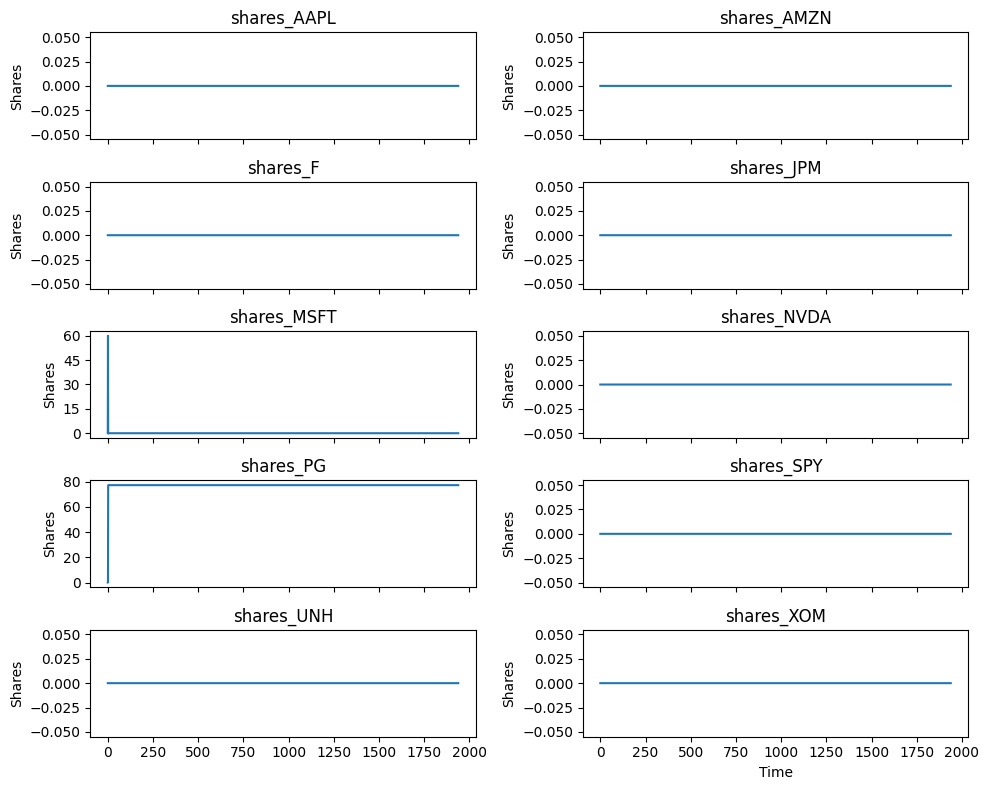

In [31]:
visualize_trading(mamba_r1[share_cols])

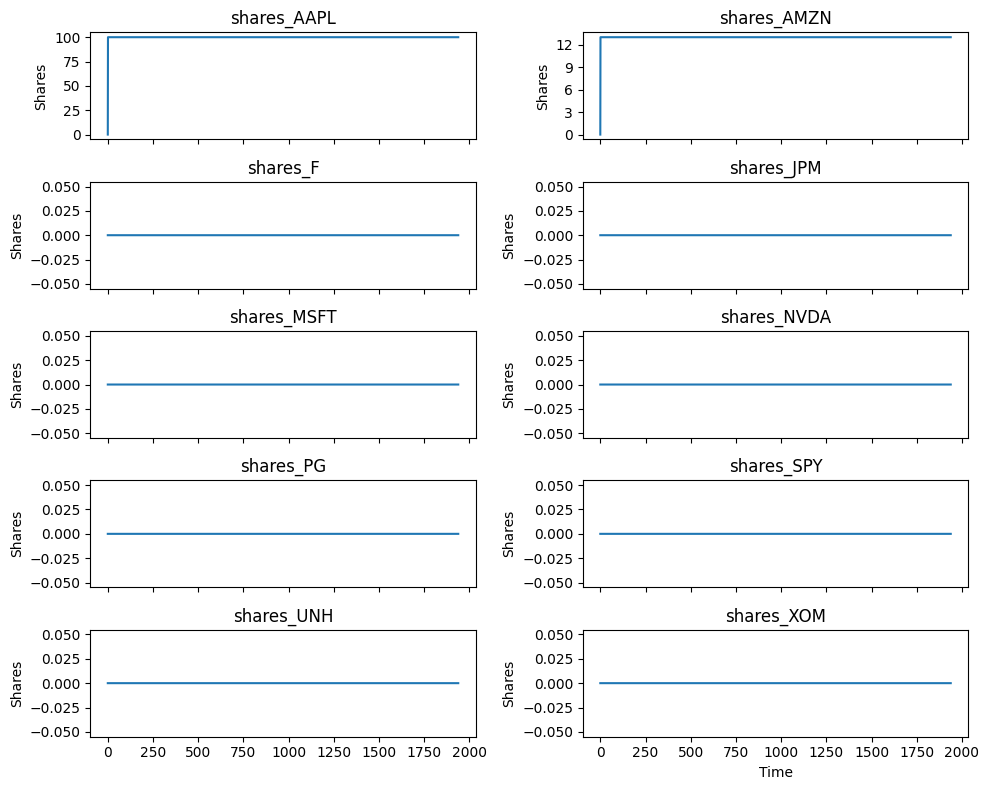

In [32]:
visualize_trading(mamba_r2[share_cols])